# Homework 6
- Complete this homework by adding answers to the appropriate cells. **Do not delte any part of this starter file.** 

- In the end, save this notebook as an html file, and then print to a pdf. Upload the python notebook and the printed pdf to Canvas.

In [35]:
# import only the necessary packages used in this HW
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Follow the `dim_reduction` notebook to draw a plot of RMSE against k
In the `dim_reduction` notebook, we have RMSE = $\$38815$ for $k=15$. Your task is to draw a 2D plot where the $x$-axis is k and the $y$-axis is RMSE. Let $k=1,2,\cdots,31$.

(It maybe a good idea to first write a function whose argument is k that returns RMSE.)

In [2]:
ames = pd.read_csv("../data/ames.csv")
ames_num = ames.select_dtypes(exclude=['object'])
y = ames['Sale_Price']
X = ames_num.iloc[:,:-3] # selecting all but the last 3 columns

In [3]:
def rmse(K, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 46)
    # centering: each column will have mean 0
    X_train_centered = X_train - X_train.mean()
    # convert to numpy
    X_train_centered_n = X_train_centered.to_numpy()
    # take SVD
    U,S,Vt = np.linalg.svd(X_train_centered_n)
    V = Vt.T
    Vk = V[:, :K]
    X_train_centered_n_transformed = X_train_centered_n@Vk
    lm_dr = LinearRegression().fit(X_train_centered_n_transformed, y_train)
    X_test_centered = X_test - X_train.mean()
    X_test_centered_n = X_test_centered.to_numpy()
    X_test_centered_n_transformed = X_test_centered_n@Vk
    return root_mean_squared_error(y_test, lm_dr.predict(X_test_centered_n_transformed))

In [4]:
# test the function
rmse(15, X, y)

38814.92805886217

In [5]:
# for loop
max_K = 31
error_val = np.zeros(max_K)
for i in range(1,max_K+1):
    error_val[i-1] = rmse(i, X, y)

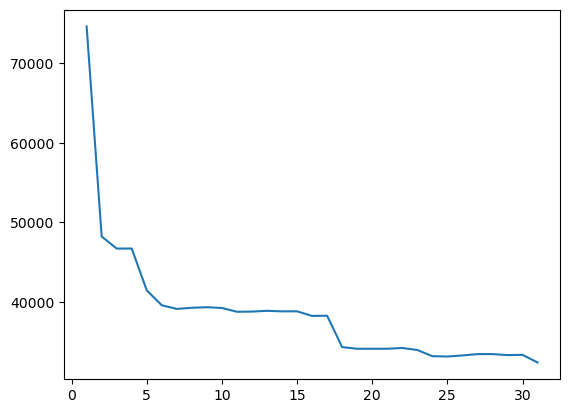

In [6]:
# plot
plt.plot(range(1, max_K+1), error_val);

## 2. Data viz when k = 2
SVD can also be a good tool to visualize data. In the `dim_reduction` notebook, there are 2930 houses. Use SVD to represent each house by a point in $\mathbb{R}^2$ (use k=2). Draw these 2930 points on an xy plane.

This is about data visualization so we do not need to do train-test split.

In [7]:
X.shape

(2930, 31)

In [27]:
X_centered = X - X.mean()
X_centered_n = X_centered.to_numpy()
Ux,Sx,Vxt = np.linalg.svd(X_centered_n)
Vx = Vxt.T
Vx_2 = Vx[:, :2]
X_centered_n_transformed = X_centered_n@Vx_2
X_centered_n_transformed.shape

(2930, 2)

In [28]:
type(X_centered_n_transformed)

numpy.ndarray

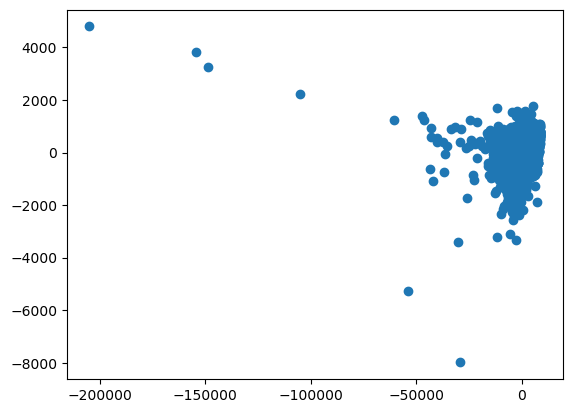

In [40]:
plt.scatter(X_centered_n_transformed[:,0], X_centered_n_transformed[:,1]);

<Axes: >

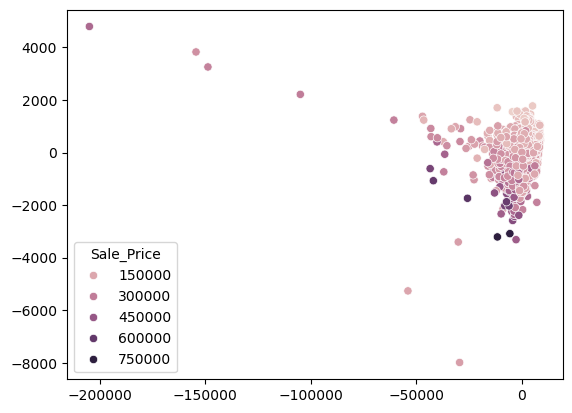

In [47]:
sns.scatterplot(x=X_centered_n_transformed[:,0], 
                y=X_centered_n_transformed[:,1], 
                hue=ames['Sale_Price'],
                )

## 3. Lasso for sparse solutions
In this homework, we will use Lasso to find the sparse solution of an under-determined linear system $Aw_0=y$. First run the cell below

In [48]:
n = 5
p = 20
np.random.seed(2000)
A = np.random.randn(n,p)
w0 = np.zeros(p)
w0[:2] = [1,2]
y = A@w0

You can think of $A$ as a data matrix. The way it has been set up, $w_0$ is a solution to the linear system $Ax=y$. However, given it's underdetermined and consistent, there are **infinitely many** solutions. 

### 3.1 Use `np.linalg.lstsq` to find a solution of $Ax=y$. Verify that it is a solution and print it.

In [32]:
?np.linalg.lstsq

In [49]:
w_ls = np.linalg.lstsq(A, y)
w_ls = w_ls[0]
w_ls

array([ 0.3684625 ,  1.20309383, -0.44751223,  0.20593228, -0.00779055,
       -0.20304698,  0.24041158,  0.2526626 , -0.47939532, -0.25750187,
        0.2391381 , -0.06269719,  0.24592782, -0.23132396,  0.21454593,
        0.27654612,  0.19155723,  0.06630385, -0.3670539 , -0.12762294])

The above is a dense solution.

In [50]:
np.sum(np.abs(A@w_ls - y))

np.float64(1.2878587085651816e-14)

### 3.2. Lasso can help us to recover this $w_0$!
For parameters, make sure you use `fit_intercept=False` in the Lasso function. Choose a very tiny `alpha` to begin with and slowly increase it. Use `coef_` to retrieve the weights $w_0$.

For what value of $\alpha$ are you able to get $w_0$ back?

In [51]:
lm_lasso = Lasso(alpha = 0.005, 
                 max_iter = 300,
                 fit_intercept = False,).fit(A, y)
w_hat = lm_lasso.coef_
w_hat

array([ 0.98826467,  1.99875202, -0.00438487,  0.        ,  0.        ,
       -0.        ,  0.        , -0.        , -0.        , -0.        ,
        0.        , -0.        ,  0.        , -0.        , -0.        ,
       -0.        ,  0.        , -0.        , -0.        , -0.        ])

## 4. Verify that Lasso gives soft thresholding opeator when $X^\top X$ is the identity matrix.
run the cell below first to create $X$ whose columns are orthonormal to each other. 

In [52]:
n = 100
p = 20
B = np.random.randn(n,p)
X,R = np.linalg.qr(B)
y = np.random.randn(n)

On one hand, use `Lasso()` to solve the optimal $w$, set it to `w1`; on the other hand, use soft thresholding to find the solution, set it to `w2`. Verify that `w1` and `w2` are the same solution.

In [ ]:
?Lasso

The Lasso documentation says it is solving the following problem:

`(1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1`

which is: 

`(1 / 2) * ||y - Xw||^2_2 + (alpha * n_samples) * ||w||_1`

Compare to Thm 3.9, we have `lambda = alpha * n_samples`

In [53]:
alp = 0.01
lam = n*alp

In [54]:
# use Lasso()
lm_lasso4 = Lasso(alpha = alp, 
                  max_iter = 300,
                  fit_intercept = False,).fit(X, y)
w1 = lm_lasso4.coef_
w1

array([ 0.        ,  0.        , -0.        ,  0.        , -0.16283591,
        0.31654519,  0.        , -0.        , -0.        ,  0.        ,
       -0.        , -0.        , -0.        ,  0.        , -0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.        ])

In [55]:
def soft_th(x, lam):
    return np.sign(x)*np.maximum(np.abs(x)-lam, 0)

In [56]:
# test soft thresholding
x = np.array([-2, 1, 3])
soft_th(x, 1.5)

array([-0.5,  0. ,  1.5])

In [57]:
w2 = soft_th(X.T@y, lam)
w2

array([ 0.        ,  0.        , -0.        ,  0.        , -0.16283591,
        0.31654519,  0.        , -0.        , -0.        ,  0.        ,
       -0.        , -0.        , -0.        ,  0.        , -0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.        ])